In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyBioInfo.IO.File import BedFile, BamFile
from pyBioInfo.Utils import BlockTools

# Plot tracks

In [2]:
transcripts = {t.name: t for t in BedFile("../../1_NanoNASCseq/results/7_assembly_custom/5_gtf_full/MouseBlastocyst.bed.gz")}
anno_t = pd.read_csv("../../1_NanoNASCseq/results/7_assembly_custom/5_gtf_full/MouseBlastocyst.gtf.transcript_info.csv", index_col=0)
for tid, tname in zip(anno_t.index, anno_t["TranscriptName"]):
    transcripts[tid].transcript_name = tname

In [3]:
def keep_alignment(isoforms, alignment):
    introns2 = tuple([(x, y) for x, y in BlockTools.gaps(alignment.blocks)])
    for isoform in isoforms:
        introns1 = tuple([(x, y) for x, y in BlockTools.gaps(isoform.blocks)])
        matched = True
        if len(introns1) == len(introns2):
            for intron1, intron2 in zip(introns1, introns2):
                if abs(intron1[0]-intron2[0]) > 5 or abs(intron1[1]-intron2[1]) > 5:
                    matched = False
                    break
        else:
            matched = False
        if matched:
            return True
    return False
    
def get_coverages(celltype, chrom, start, end, isoforms=None):
    covs = np.zeros(end - start)
    with BamFile("../3_pseudobulk/results/bams/MouseBlastocyst_%s.s4U_400uM_3h.bam" % celltype, random=True) as f:
        for a in f.fetch(chrom, start, end):
            if isoforms is not None and not keep_alignment(isoforms, a):
                continue
            for x, y in a.blocks:
                x, y = max(start, x), min(end, y)
                if x < y:
                    for i in range(x - start, y - start):
                        covs[i] += 1

    for line in open("../3_pseudobulk/results/bams/MouseBlastocyst_%s.s4U_400uM_3h.flagstat" % celltype):
        size = int(line.strip().split()[0])
        break
    covs = covs * 1000000 / size
    return covs    

def plot_coverages(ax, ct, start, end, coverages, xlims, ylims):
    ax0 = plt.gca()
    plt.sca(ax)
    plt.xlim(*xlims)
    plt.ylim(*ylims)
    plt.xticks([])
    plt.yticks([])
    plt.text(xlims[0] + (xlims[1] - xlims[0]) * 0.01, ylims[0] + (ylims[1] - ylims[0]) * 0.9, "[0-%s]" % format(ylims[1], ','), ha="left", va="top")
    plt.ylabel(ct, ha="right", va="center", rotation=0)       
    ys = coverages
    xs = np.arange(start, end)
    plt.fill_between(xs, 0, ys, color="black", lw=0)
    plt.sca(ax0)

def plot_isoforms(ax, start, end, isoforms, xlims):
    ax0 = plt.gca()
    plt.sca(ax)
    plt.xlim(*xlims)
    plt.xticks([])
    for i, t in enumerate(isoforms):
        color = "C0" if t.strand == "+" else "C3"
        plt.text(t.start - (xlims[1] - xlims[0]) * 0.01, i + 0.5, t.transcript_name, ha="right", va="center")
        plt.plot([t.start, t.end], [i + 0.5, i + 0.5], color=color, lw=1)
        thick1 = 0.3 # exon
        thick2 = 0.6 # CDS
        for block in t.blocks:
            plt.fill_between([block[0], block[1]], 
                             [i + 0.5 - thick1 / 2, i + 0.5 - thick1 / 2], 
                             [i + 0.5 + thick1 / 2, i + 0.5 + thick1 / 2], lw=0.5, color=color, zorder=10)
        if t.thick:
            for block in t.blocks:
                x1, x2 = max(block[0], t.thick[0]), min(block[1], t.thick[1])
                if x1 >= x2:
                    continue
                plt.fill_between([x1, x2], 
                                 [i + 0.5 - thick2 / 2, i + 0.5 - thick2 / 2], 
                                 [i + 0.5 + thick2 / 2, i + 0.5 + thick2 / 2], lw=0.5, color=color, zorder=10)
    plt.ylim(len(isoforms), 0)
    plt.yticks([])
    plt.sca(ax0)

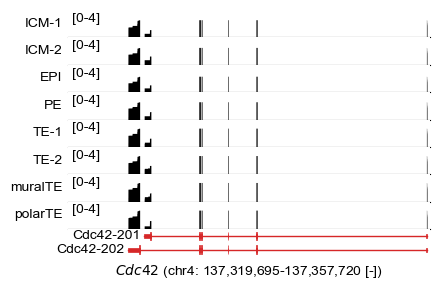

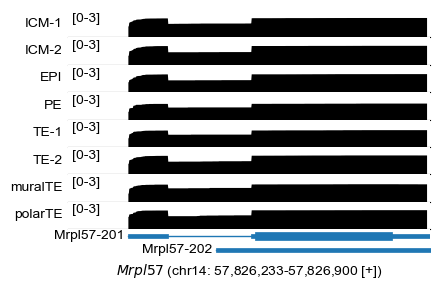

In [11]:
for gname in ["Cdc42", "Dppa1", "Mrpl57"]:
    
    if gname == "Cdc42":
        tnames = ["Cdc42-201", "Cdc42-202"]
        # ylim = 2500 # 2500
        ylim = 4
    elif gname == "Dppa1":
        tnames = ["Dppa1-201", "Dppa1-202"]
        ylim = 4 # 1500
        continue
    elif gname == "Mrpl57":
        tnames = ["Mrpl57-201", "Mrpl57-202"]
        ylim = 3
        # ylim = 250
        
    tids = [anno_t[anno_t["TranscriptName"] == i].index.values[0] for i in tnames]
    isoforms = [transcripts[tid] for tid in tids]
    chrom = isoforms[0].chrom
    start = min([t.start for t in isoforms])
    end = max([t.end for t in isoforms])
    strand = isoforms[0].strand
    if gname == "Mrpl57":
        end = 57826900
    
    cts = ["ICM-1", "ICM-2", "EPI", "PE", "TE-1", "TE-2", "muralTE", "polarTE"]
    # cts = ["TE-1", "TE-2", "muralTE", "polarTE"]
    coverages_list = []
    for ct in cts:
        #coverages = get_coverages(ct, chrom, start, end, None)
        coverages = get_coverages(ct, chrom, start, end, isoforms)
        coverages = np.log10(coverages + 1) # convert coverage values to log10
        coverages_list.append(coverages)
    
    xlims = [start - (end - start) * 0.2, end + (end - start) * 0.01]
    ylims = [0, ylim]
    
    fig, axs = plt.subplots(len(cts) + 1, 1, figsize=(4.5, 3), gridspec_kw={"hspace": 0, "wspace": 0})
    for i, ct in enumerate(cts):
        plot_coverages(axs[i], ct, start, end, coverages_list[i], xlims, ylims)
    plot_isoforms(axs[-1], start, end, isoforms, xlims)
    for ax in axs:
        for loc in ["left", "right", "top"]:
            ax.spines[loc].set_visible(False)
    axs[-1].spines["bottom"].set_visible(False)
    axs[-1].set_xlabel("$\it{%s}$ (%s: %s-%s [%s])" % (gname, chrom, format(start, ","), format(end, ","), strand))
    plt.tight_layout()
    plt.savefig("figures/tracks_of_%s.v2.pdf" % gname)
    plt.show()
    plt.close()

    # break

# Plot tracks (old version)

In [16]:
transcripts = {t.name: t for t in BedFile("../../1_NanoNASCseq/results/7_assembly_custom/5_gtf_full/MouseBlastocyst.bed.gz")}
anno_t = pd.read_csv("../../1_NanoNASCseq/results/7_assembly_custom/5_gtf_full/MouseBlastocyst.gtf.transcript_info.csv", index_col=0)
for tid, tname in zip(anno_t.index, anno_t["TranscriptName"]):
    transcripts[tid].transcript_name = tname

In [21]:
def keep_alignment(isoforms, alignment):
    introns2 = tuple([(x, y) for x, y in BlockTools.gaps(alignment.blocks)])
    for isoform in isoforms:
        introns1 = tuple([(x, y) for x, y in BlockTools.gaps(isoform.blocks)])
        if introns1 == introns2:
            return True
    return False

def get_coverages(celltype, chrom, start, end):
    covs = np.zeros(end - start)
    with BamFile("../3_pseudobulk/results/bams/MouseBlastocyst_%s.s4U_400uM_3h.bam" % celltype, random=True) as f:
        for a in f.fetch(chrom, start, end):
            for x, y in a.blocks:
                x, y = max(start, x), min(end, y)
                if x < y:
                    for i in range(x - start, y - start):
                        covs[i] += 1

    for line in open("../3_pseudobulk/results/bams/MouseBlastocyst_%s.s4U_400uM_3h.flagstat" % celltype):
        size = int(line.strip().split()[0])
        break
    covs = covs * 1000000 / size
    return covs    

def plot_coverages(ax, ct, start, end, coverages, xlims, ylims):
    ax0 = plt.gca()
    plt.sca(ax)
    plt.xlim(*xlims)
    plt.ylim(*ylims)
    plt.xticks([])
    plt.yticks([])
    plt.text(xlims[0] + (xlims[1] - xlims[0]) * 0.01, ylims[0] + (ylims[1] - ylims[0]) * 0.9, "[0-%s]" % format(ylims[1], ','), ha="left", va="top")
    mapper = {
        "ICM1": "ICM-1", 
        "ICM2": "ICM-2", 
        "TE1": "TE-1",
        "TE2": "TE-2",
        "MuralTE": "muralTE", 
        "PolarTE": "polarTE"
    }
    plt.ylabel(mapper.get(ct, ct), ha="right", va="center", rotation=0)       
    ys = coverages
    xs = np.arange(start, end)
    plt.fill_between(xs, 0, ys, color="black", lw=0)
    plt.sca(ax0)

def plot_isoforms(ax, start, end, isoforms, xlims):
    ax0 = plt.gca()
    plt.sca(ax)
    plt.xlim(*xlims)
    plt.xticks([])
    for i, t in enumerate(isoforms):
        color = "C0" if t.strand == "+" else "C3"
        plt.text(t.start - (xlims[1] - xlims[0]) * 0.01, i + 0.5, t.transcript_name, ha="right", va="center")
        plt.plot([t.start, t.end], [i + 0.5, i + 0.5], color=color, lw=1)
        thick1 = 0.3 # exon
        thick2 = 0.6 # CDS
        for block in t.blocks:
            plt.fill_between([block[0], block[1]], 
                             [i + 0.5 - thick1 / 2, i + 0.5 - thick1 / 2], 
                             [i + 0.5 + thick1 / 2, i + 0.5 + thick1 / 2], lw=0.5, color=color, zorder=10)
        if t.thick:
            for block in t.blocks:
                x1, x2 = max(block[0], t.thick[0]), min(block[1], t.thick[1])
                if x1 >= x2:
                    continue
                plt.fill_between([x1, x2], 
                                 [i + 0.5 - thick2 / 2, i + 0.5 - thick2 / 2], 
                                 [i + 0.5 + thick2 / 2, i + 0.5 + thick2 / 2], lw=0.5, color=color, zorder=10)
    plt.ylim(len(isoforms), 0)
    plt.yticks([])
    plt.sca(ax0)

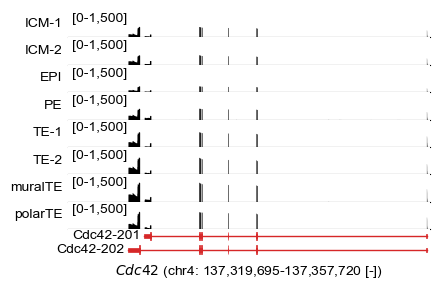

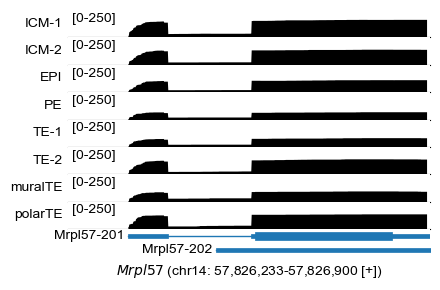

In [22]:
for gname in ["Cdc42", "Dppa1", "Mrpl57"]:
    
    if gname == "Cdc42":
        tnames = ["Cdc42-201", "Cdc42-202"]
        ylim = 1500
    elif gname == "Dppa1":
        tnames = ["Dppa1-201", "Dppa1-202"]
        ylim = 2500
        continue
    elif gname == "Mrpl57":
        tnames = ["Mrpl57-201", "Mrpl57-202"]
        ylim = 250
        
    tids = [anno_t[anno_t["TranscriptName"] == i].index.values[0] for i in tnames]
    isoforms = [transcripts[tid] for tid in tids]
    chrom = isoforms[0].chrom
    start = min([t.start for t in isoforms])
    end = max([t.end for t in isoforms])
    strand = isoforms[0].strand
    if gname == "Mrpl57":
        end = 57826900
    
    cts = ["ICM1", "ICM2", "EPI", "PE", "TE1", "TE2", "MuralTE", "PolarTE"]
    # cts = ["TE-1", "TE-2", "muralTE", "polarTE"]
    coverages_list = []
    for ct in cts:
        coverages = get_coverages(ct, chrom, start, end)
        if gname == "Cdc42": # TODO: under estimate coverage because ISM (decay).
            for i in range(2066, 2924):
                coverages[i] = coverages[i] * 8
        if gname == "Dppa1":
            for i in range(19147, 19233):
                coverages[i] = coverages[i] * 1.5
        coverages_list.append(coverages)
    
    xlims = [start - (end - start) * 0.2, end + (end - start) * 0.01]
    ylims = [0, ylim]
    
    fig, axs = plt.subplots(len(cts) + 1, 1, figsize=(4.5, 3), gridspec_kw={"hspace": 0, "wspace": 0})
    for i, ct in enumerate(cts):
        plot_coverages(axs[i], ct, start, end, coverages_list[i], xlims, ylims)
    plot_isoforms(axs[-1], start, end, isoforms, xlims)
    for ax in axs:
        for loc in ["left", "right", "top"]:
            ax.spines[loc].set_visible(False)
    axs[-1].spines["bottom"].set_visible(False)
    axs[-1].set_xlabel("$\it{%s}$ (%s: %s-%s [%s])" % (gname, chrom, format(start, ","), format(end, ","), strand))
    plt.tight_layout()
    plt.savefig("figures/tracks_of_%s.pdf" % gname)
    plt.show()
    plt.close()

# Plot pie

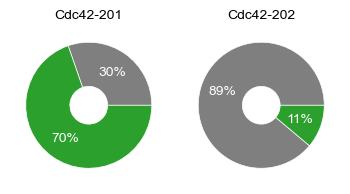

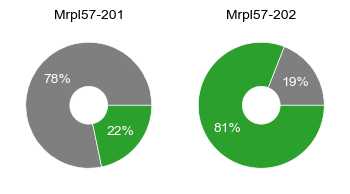

In [54]:
for ct in ["polarTE", "EPI"]:
    m = pd.read_csv("../3_pseudobulk/results/pseudobulk/MouseBlastocyst_%s.s4U_400uM_3h.transcript_based.annotated.csv" % ct)

    if ct == "polarTE":
        tnames = ["Cdc42-201", "Cdc42-202"]
    elif ct == "EPI":
        tnames = ["Mrpl57-201", "Mrpl57-202"]
    else:
        assert False
        
    fig, axs = plt.subplots(1, 2, figsize=(3.6, 2))
    for i, tname in enumerate(tnames):
        tmp = m[m["TranscriptName"] == tname]
        total, new = tmp["Total"].values[0], tmp["New"].values[0]
        plt.sca(axs[i])
        plt.title(tname, size=10)
        plt.pie([total - new, new], colors=["C7", "C2"], 
                autopct="%.0f%%", pctdistance=0.65, 
                textprops=dict(color="white"),
                wedgeprops=dict(width=0.7, lw=0.5, edgecolor="white"))
    plt.tight_layout()
    plt.savefig("figures/proportion_of_new_umi.%s.%s.pie.pdf" % (ct, tnames[0].split("-")[0]))
    plt.show()
    plt.close()